<figure>
    <picture>
        <source srcset="assets/jii-logo.png" style="max-height: 10rem;">
        <img src="https://raw.githubusercontent.com/Computational-Biology-Aachen/2026-photosynthesis-hackathon-template/refs/heads/main/assets/jii-logo.png" style="max-height: 10rem;">
    </picture>
</figure>

# Grebbedijk potato (R)

This notebook contains example analysis for the Grebbedijk potato data kindly supplied by the JII

|                        |                                  |
| ---------------------- | -------------------------------- |
| **Crop**               | Potato                           |
| **Location**           | Wageningen, Netherlands          |
| **Year**               | 2025                             |
| **Measurements**       | 3,681                            |
| **Genotypes**          | 48 plots                         |
| **Owner**              | Olivia Kacheyo                   |
| **Protocol**           | UNZA_PIRK_DIRK_LightPotential_14 |
| **PhotosynQ projects** | 33338                            |

**Experiment:** Assessment of photosynthesis dynamics in a potato field trial at Grebbedijk (Wageningen). 48 plots measured with MultispeQ, genotype assigned via plot layout key.

**Protocol features (UNZA_PIRK_DIRK):** This protocol measures photosynthesis under both ambient and high (saturating) actinic light, enabling calculation of "light potential" — the difference between current and maximum electron transport rate. It also includes PIRK (Post-Illumination Rise in fluorescence Kinetics), an indicator of cyclic electron flow around PSI.

**Computed columns (25):**

| Category       | Columns                                                                                                                                          |
| -------------- | ------------------------------------------------------------------------------------------------------------------------------------------------ |
| Photosynthesis | `phi2_ambient`, `phi2_high`, `LEF_ambient`, `LEF_high`, `LEF_light_potential`                                                                    |
| Light          | `PAR`, `used_PAR_ambient`, `used_PAR_high`, `SQRT_PAR`                                                                                           |
| Chlorophyll    | `SPAD`                                                                                                                                           |
| Environment    | `ambient_Temperature`, `leaf_temperature`, `leaf_temperature_differential`, `humidity`, `pressure`, `leaf_angle`                                 |
| PIRK           | `PIRK_amp_ambient`, `PIRK_amp_high`, `pirk_intensity`                                                                                            |
| Autogain       | `autogain_ch1_duration`, `autogain_ch1_intensity`, `autogain_ch1_value`, `autogain_ch2_duration`, `autogain_ch2_intensity`, `autogain_ch2_value` |
| Timing         | `measurement_duration_sec`                                                                                                                       |

**Additional column:** `sample_raw` (VARIANT) — full raw measurement trace from the MultispeQ device, containing time-resolved fluorescence, absorbance, and environmental sensor data. Can be parsed for additional phenotypes beyond the computed columns.

In [7]:
# Install packages (only needed on first run)
install.packages(c("ggplot2", "dplyr", "tidyr", "patchwork", "nanoparquet"),
                 repos = "https://cloud.r-project.org")

Installing packages into ‘/home/dv/R/x86_64-redhat-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)



In [8]:
library(ggplot2)
library(dplyr)
library(tidyr)

CATALOG <- "open_jii_data_hackathon.default"
TABLE <- "grebbedijk_measurements"

# Detect environment: Databricks (sparklyr) or local (arrow/parquet)
in_databricks <- tryCatch({
  library(sparklyr)
  sc <- spark_connect(method = "databricks")
  TRUE
}, error = function(e) FALSE)

if (in_databricks) {
  message("Running on Databricks — loading via Spark SQL")
  df <- sdf_sql(sc, paste0("SELECT * EXCEPT(sample_raw) FROM ", CATALOG, ".", TABLE)) |>
    collect()
} else {
  message("Running locally — loading from parquet")
  library(nanoparquet)
  df <- read_parquet(file.path("data", paste0(TABLE, ".parquet")))
}

# Parse timestamp
df$timestamp <- as.POSIXct(df$timestamp)

str(df)

Running locally — loading from parquet



Classes ‘tbl’ and 'data.frame':	3681 obs. of  52 variables:
 $ measurement_id               : chr  "5621984" "5621983" "5621982" "5621981" ...
 $ project_id                   : chr  "33338" "33338" "33338" "33338" ...
 $ user_id                      : chr  "142465" "142465" "142465" "142465" ...
 $ device_id                    : chr  "11:16:69:38" "11:16:69:38" "11:16:69:38" "11:16:69:38" ...
 $ status                       : chr  "submitted" "submitted" "submitted" "submitted" ...
 $ timestamp                    : POSIXct, format: "2025-08-14 06:09:47" "2025-08-14 06:10:40" ...
 $ latitude                     : num  52 52 52 52 52 ...
 $ longitude                    : num  5.63 5.63 5.63 5.63 5.63 ...
 $ plot_number                  : num  38 37 41 42 44 48 47 46 33 35 ...
 $ plant_measured               : chr  "Plant 1_Extra" "Plant 1_Extra" "Plant 1_Extra" "Plant 1_Extra" ...
 $ stems_count                  : chr  "1" "1" "1" "1" ...
 $ Name                         : chr  "ING 02-14

## Analyse distribution of data

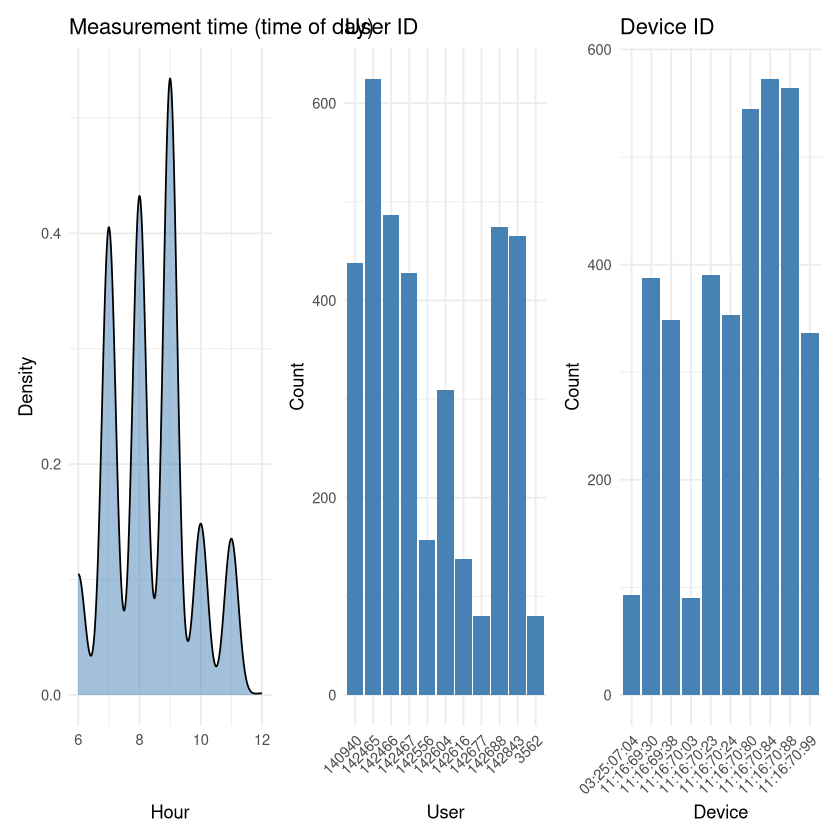

In [9]:
# Measurement time of day
p1 <- ggplot(df, aes(x = as.numeric(format(timestamp, "%H")))) +
  geom_density(fill = "steelblue", alpha = 0.5) +
  labs(title = "Measurement time (time of day)", x = "Hour", y = "Density") +
  theme_minimal()

# User ID counts
p2 <- ggplot(df, aes(x = factor(user_id))) +
  geom_bar(fill = "steelblue") +
  labs(title = "User ID", x = "User", y = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Device ID counts
p3 <- ggplot(df, aes(x = factor(device_id))) +
  geom_bar(fill = "steelblue") +
  labs(title = "Device ID", x = "Device", y = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

library(patchwork)
p1 + p2 + p3

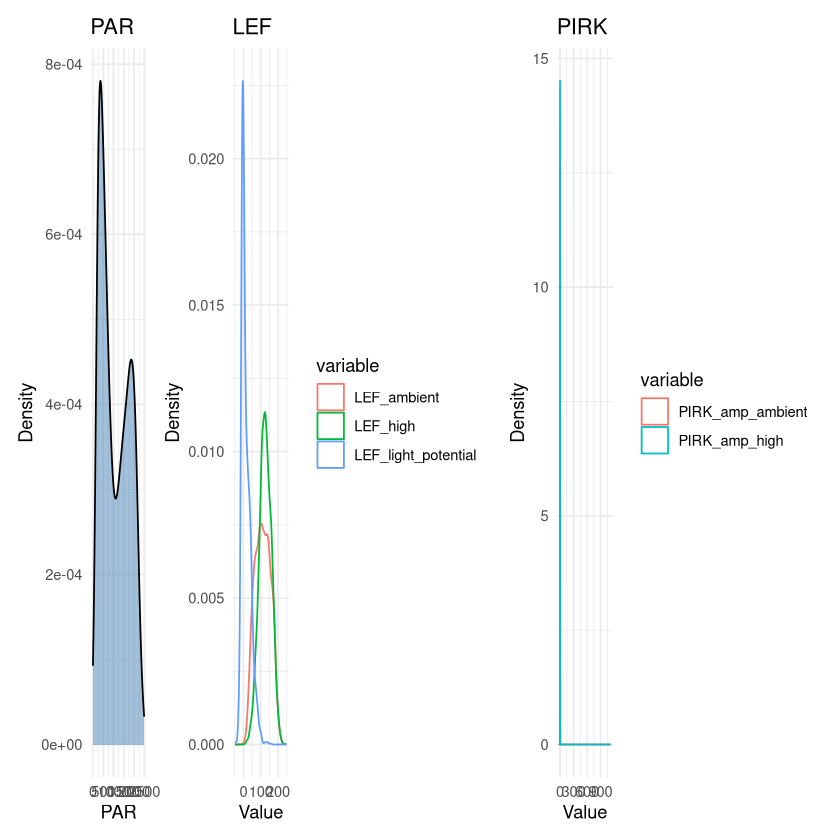

In [10]:
# PAR density
p4 <- ggplot(df, aes(x = PAR)) +
  geom_density(fill = "steelblue", alpha = 0.5) +
  labs(title = "PAR", x = "PAR", y = "Density") +
  xlim(0, NA) +
  theme_minimal()

# LEF density (ambient, high, light potential)
lef_long <- df |>
  select(LEF_ambient, LEF_high, LEF_light_potential) |>
  pivot_longer(everything(), names_to = "variable", values_to = "value")

p5 <- ggplot(lef_long, aes(x = value, color = variable)) +
  geom_density() +
  labs(title = "LEF", x = "Value", y = "Density") +
  theme_minimal()

# PIRK density
pirk_long <- df |>
  select(PIRK_amp_ambient, PIRK_amp_high) |>
  pivot_longer(everything(), names_to = "variable", values_to = "value")

p6 <- ggplot(pirk_long, aes(x = value, color = variable)) +
  geom_density() +
  labs(title = "PIRK", x = "Value", y = "Density") +
  theme_minimal()

p4 + p5 + p6

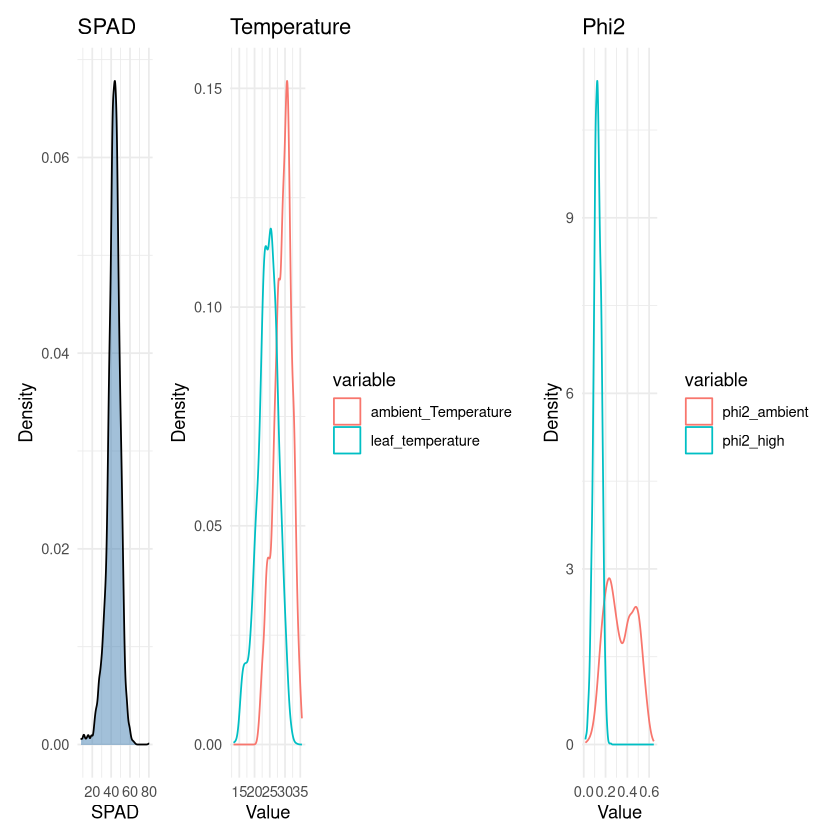

In [11]:
# SPAD density
p7 <- ggplot(df, aes(x = SPAD)) +
  geom_density(fill = "steelblue", alpha = 0.5) +
  labs(title = "SPAD", x = "SPAD", y = "Density") +
  theme_minimal()

# Temperature density (ambient + leaf)
temp_long <- df |>
  select(ambient_Temperature, leaf_temperature) |>
  pivot_longer(everything(), names_to = "variable", values_to = "value")

p8 <- ggplot(temp_long, aes(x = value, color = variable)) +
  geom_density() +
  labs(title = "Temperature", x = "Value", y = "Density") +
  theme_minimal()

# Phi2 density (ambient + high)
phi2_long <- df |>
  select(phi2_ambient, phi2_high) |>
  pivot_longer(everything(), names_to = "variable", values_to = "value")

p9 <- ggplot(phi2_long, aes(x = value, color = variable)) +
  geom_density() +
  labs(title = "Phi2", x = "Value", y = "Density") +
  theme_minimal()

p7 + p8 + p9

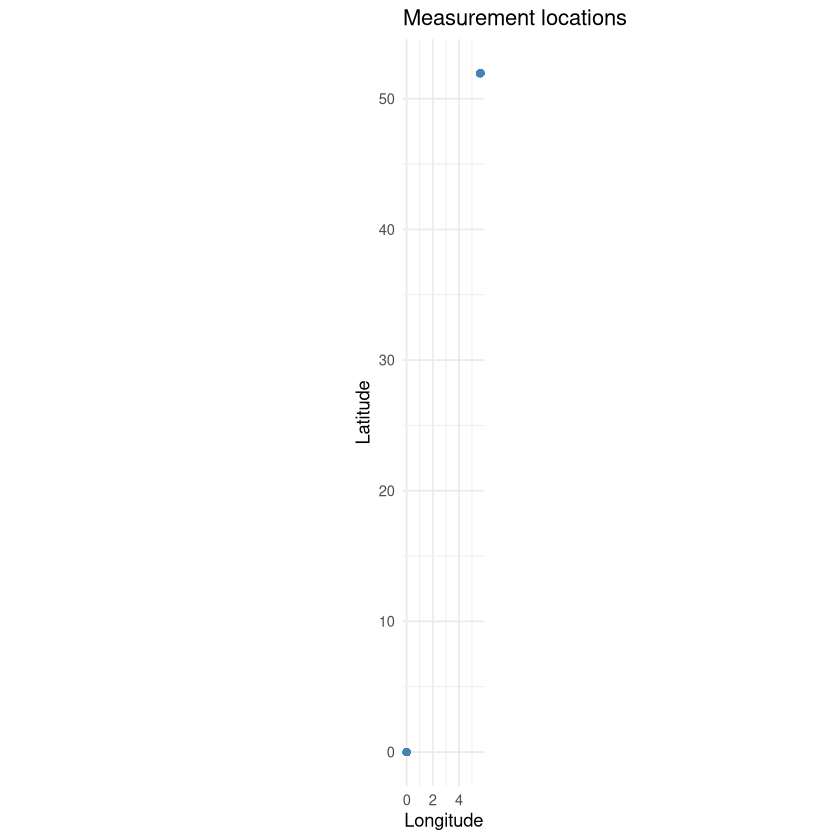

In [12]:
# Map of measurement locations (simple scatter — no sf dependency)
ggplot(df, aes(x = longitude, y = latitude)) +
  geom_point(color = "steelblue", alpha = 0.5, size = 1.5) +
  labs(title = "Measurement locations",
       x = "Longitude", y = "Latitude") +
  coord_fixed() +
  theme_minimal()

## Correlation heatmap

Phenotype correlations across all measurements — which traits co-vary?

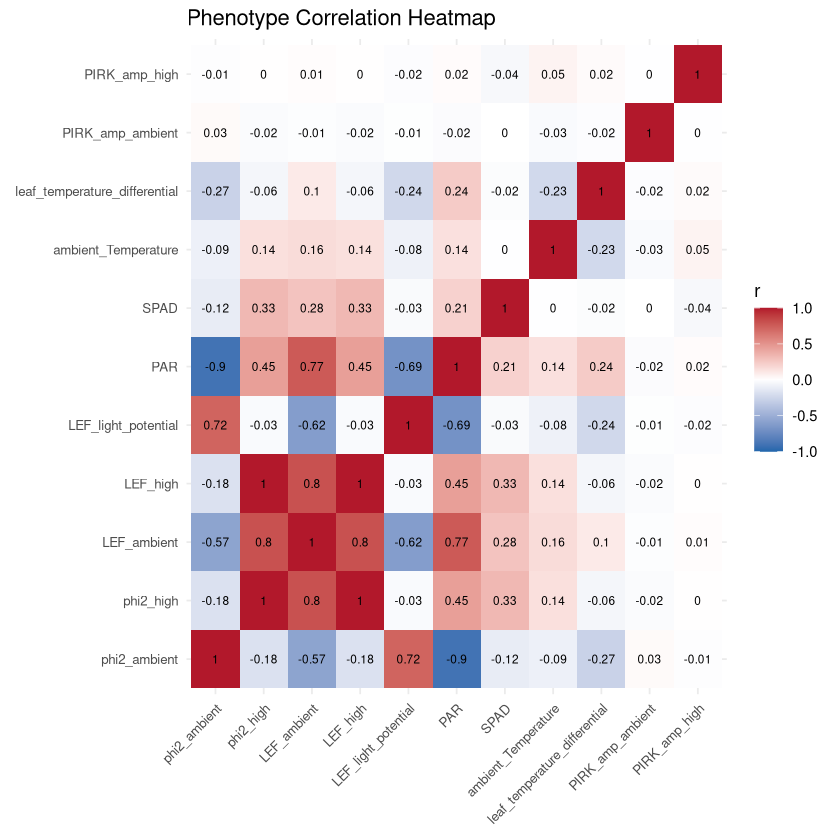

In [13]:
phenotype_cols <- c(
  "phi2_ambient", "phi2_high", "LEF_ambient", "LEF_high", "LEF_light_potential",
  "PAR", "SPAD", "ambient_Temperature", "leaf_temperature_differential",
  "PIRK_amp_ambient", "PIRK_amp_high"
)

cor_mat <- cor(df[phenotype_cols], use = "pairwise.complete.obs")

# Heatmap with ggplot2
cor_long <- as.data.frame(as.table(cor_mat))
names(cor_long) <- c("Var1", "Var2", "value")

ggplot(cor_long, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  geom_text(aes(label = round(value, 2)), size = 2.5) +
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Phenotype Correlation Heatmap", fill = "r") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 8),
        axis.text.y = element_text(size = 8),
        axis.title = element_blank())

## PAR vs Phi2 — light response curve

The relationship between light intensity (PAR) and quantum yield (Phi2) reveals
the photosynthetic light response. Under low light Phi2 is high; as PAR increases,
reaction centres saturate and Phi2 drops. The "light potential" (LEF_high - LEF_ambient)
shows how much additional electron transport is possible.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


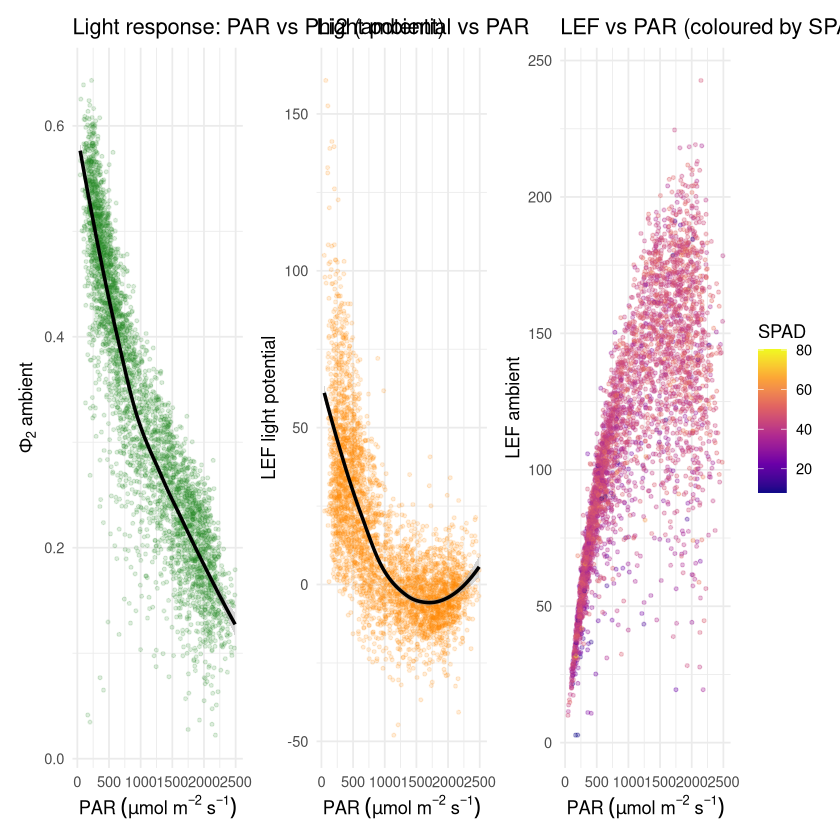

In [14]:
p_lr1 <- ggplot(df, aes(x = PAR, y = phi2_ambient)) +
  geom_point(alpha = 0.15, size = 0.8, color = "forestgreen") +
  geom_smooth(method = "loess", color = "black", linewidth = 1) +
  labs(title = "Light response: PAR vs Phi2 (ambient)",
       x = expression(PAR ~ (mu*mol ~ m^{-2} ~ s^{-1})),
       y = expression(Phi[2] ~ ambient)) +
  theme_minimal()

p_lr2 <- ggplot(df, aes(x = PAR, y = LEF_light_potential)) +
  geom_point(alpha = 0.15, size = 0.8, color = "darkorange") +
  geom_smooth(method = "loess", color = "black", linewidth = 1) +
  labs(title = "Light potential vs PAR",
       x = expression(PAR ~ (mu*mol ~ m^{-2} ~ s^{-1})),
       y = "LEF light potential") +
  theme_minimal()

p_lr3 <- ggplot(df, aes(x = PAR, y = LEF_ambient, color = SPAD)) +
  geom_point(alpha = 0.3, size = 0.8) +
  scale_color_viridis_c(option = "C") +
  labs(title = "LEF vs PAR (coloured by SPAD)",
       x = expression(PAR ~ (mu*mol ~ m^{-2} ~ s^{-1})),
       y = "LEF ambient", color = "SPAD") +
  theme_minimal()

p_lr1 + p_lr2 + p_lr3

## Genotype analysis

Compare photosynthesis performance across the 48 potato genotypes.
Boxplots reveal genetic variation in key traits; genotype ranking
highlights the best and worst performers.

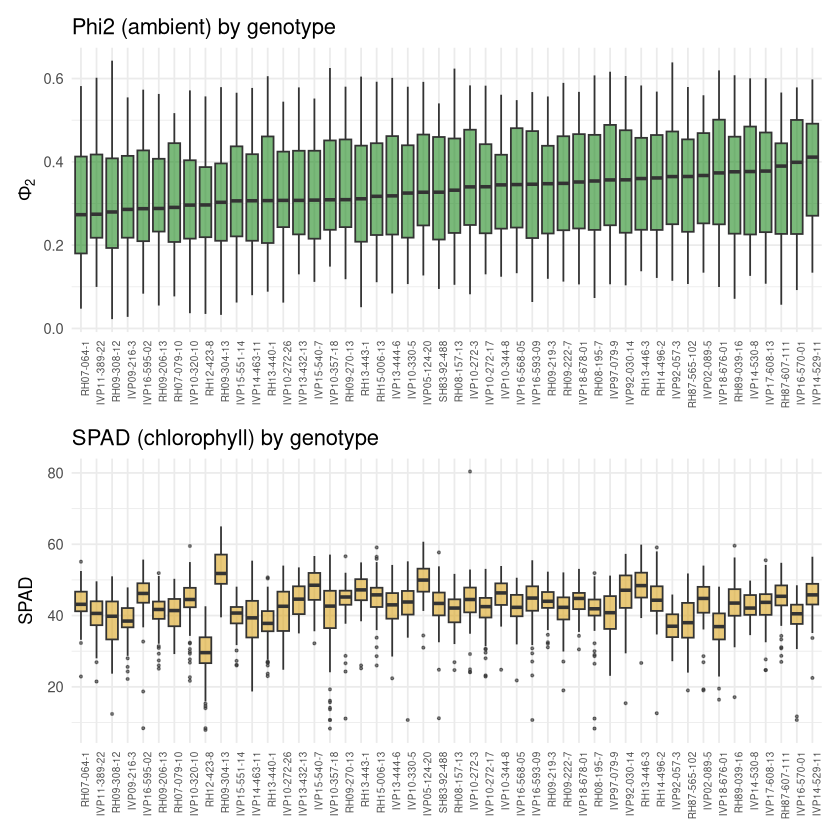

In [15]:
# Boxplots of key phenotypes by genotype (ordered by median phi2)
geno_order <- df |>
  group_by(Genotype) |>
  summarise(med_phi2 = median(phi2_ambient, na.rm = TRUE)) |>
  arrange(med_phi2) |>
  pull(Genotype)

df$Genotype_f <- factor(df$Genotype, levels = geno_order)

p_g1 <- ggplot(df, aes(x = Genotype_f, y = phi2_ambient)) +
  geom_boxplot(fill = "forestgreen", alpha = 0.6, outlier.size = 0.5) +
  labs(title = "Phi2 (ambient) by genotype", x = NULL, y = expression(Phi[2])) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 6))

p_g2 <- ggplot(df, aes(x = Genotype_f, y = SPAD)) +
  geom_boxplot(fill = "goldenrod", alpha = 0.6, outlier.size = 0.5) +
  labs(title = "SPAD (chlorophyll) by genotype", x = NULL, y = "SPAD") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 6))

p_g1 / p_g2

In [16]:
# Genotype summary table — ranked by mean Phi2
geno_summary <- df |>
  group_by(Genotype) |>
  summarise(
    n = n(),
    phi2_mean     = mean(phi2_ambient, na.rm = TRUE),
    phi2_sd       = sd(phi2_ambient, na.rm = TRUE),
    LEF_mean      = mean(LEF_ambient, na.rm = TRUE),
    light_pot     = mean(LEF_light_potential, na.rm = TRUE),
    SPAD_mean     = mean(SPAD, na.rm = TRUE),
    PIRK_mean     = mean(PIRK_amp_ambient, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(phi2_mean))

print(paste("Top 10 genotypes by Phi2:"))
head(geno_summary, 10)

print(paste("Bottom 10 genotypes by Phi2:"))
tail(geno_summary, 10)

[1] "Top 10 genotypes by Phi2:"


Genotype,n,phi2_mean,phi2_sd,LEF_mean,light_pot,SPAD_mean,PIRK_mean
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IVP14-529-11,79,0.3878089,0.1309542,118.3487,16.30620,45.75570,0.1732532
IVP18-676-01,79,0.3667456,0.1455996,107.4985,14.80228,36.41899,0.2329114
IVP14-530-8,79,0.3656203,0.1369728,114.0349,21.52886,42.75570,0.1567595
IVP97-079-9,79,0.3636937,0.1407370,111.6601,14.20354,40.21772,0.1728481
IVP16-570-01,79,0.3629810,0.1512332,110.6110,20.63620,39.73671,0.2783291
IVP92-057-3,79,0.3602835,0.1287201,111.7729,12.58848,36.77722,0.1915443
IVP16-568-05,79,0.3600342,0.1271229,117.2858,17.43835,42.19367,0.1378228
IVP02-089-5,79,0.3596886,0.1250423,109.6818,18.63937,43.61772,1.9012025
IVP10-272-3,79,0.3551000,0.1259257,120.8156,17.15392,44.07975,6.7360253


[1] "Bottom 10 genotypes by Phi2:"


Genotype,n,phi2_mean,phi2_sd,LEF_mean,light_pot,SPAD_mean,PIRK_mean
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IVP14-463-11,60,0.3214867,0.1341717,98.71183,14.324833,38.62500,0.1399667
RH09-206-13,60,0.3203000,0.1266424,116.76450,8.647833,40.98500,0.1609500
RH07-079-10,67,0.3194060,0.1315682,105.80642,18.101791,40.45970,0.1981045
IVP11-389-22,78,0.3154936,0.1357049,115.34154,9.480128,39.92308,0.1828846
IVP09-216-3,68,0.3107353,0.1332466,110.55309,10.667647,38.63971,0.1667647
IVP10-320-10,78,0.3031603,0.1223462,100.64192,7.268974,43.39359,0.1779615
RH12-423-8,67,0.2999284,0.1255532,100.41881,12.222090,28.98507,0.1794776
RH07-064-1,76,0.2997816,0.1409734,107.38329,6.296053,43.45789,0.1681316
RH09-304-13,79,0.2984038,0.1217866,108.25722,15.028608,52.65063,0.1930127


## Parentage analysis

Each genotype has known female and male parents. Grouping by parent reveals
whether certain breeding lines contribute to higher photosynthetic performance.

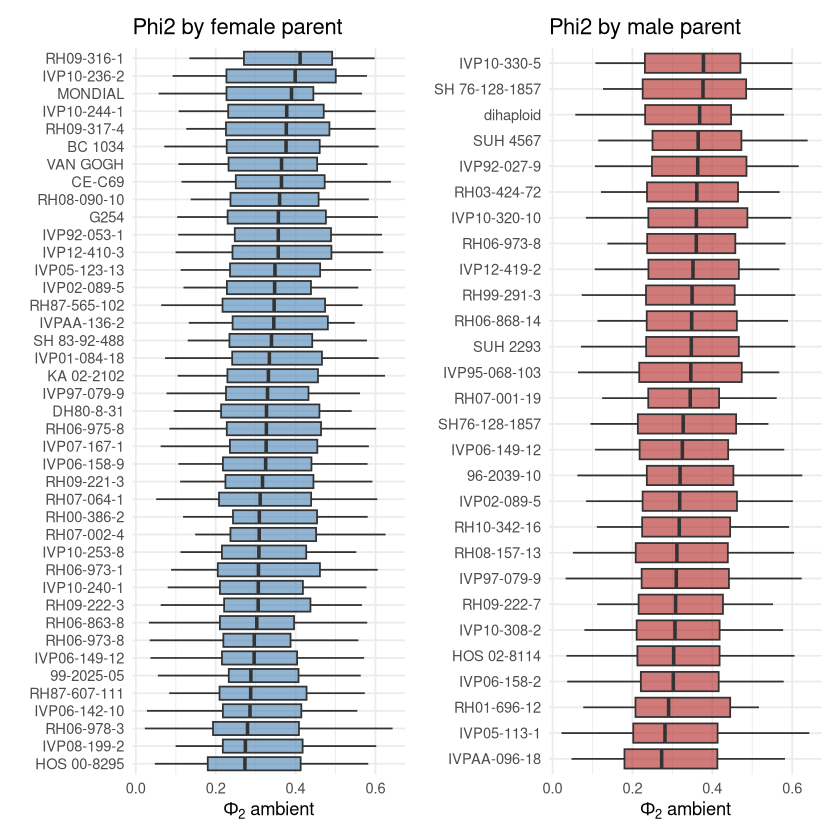

In [17]:
# Phi2 by female parent
p_f <- df |>
  filter(!is.na(female)) |>
  ggplot(aes(x = reorder(female, phi2_ambient, FUN = median), y = phi2_ambient)) +
  geom_boxplot(fill = "steelblue", alpha = 0.6, outlier.size = 0.5) +
  coord_flip() +
  labs(title = "Phi2 by female parent", x = NULL, y = expression(Phi[2] ~ ambient)) +
  theme_minimal()

# Phi2 by male parent
p_m <- df |>
  filter(!is.na(male)) |>
  ggplot(aes(x = reorder(male, phi2_ambient, FUN = median), y = phi2_ambient)) +
  geom_boxplot(fill = "firebrick", alpha = 0.6, outlier.size = 0.5) +
  coord_flip() +
  labs(title = "Phi2 by male parent", x = NULL, y = expression(Phi[2] ~ ambient)) +
  theme_minimal()

p_f + p_m

## Time-of-day effect

Environmental conditions change throughout the day (light, temperature, humidity).
This affects photosynthesis measurements and should be considered when comparing genotypes.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


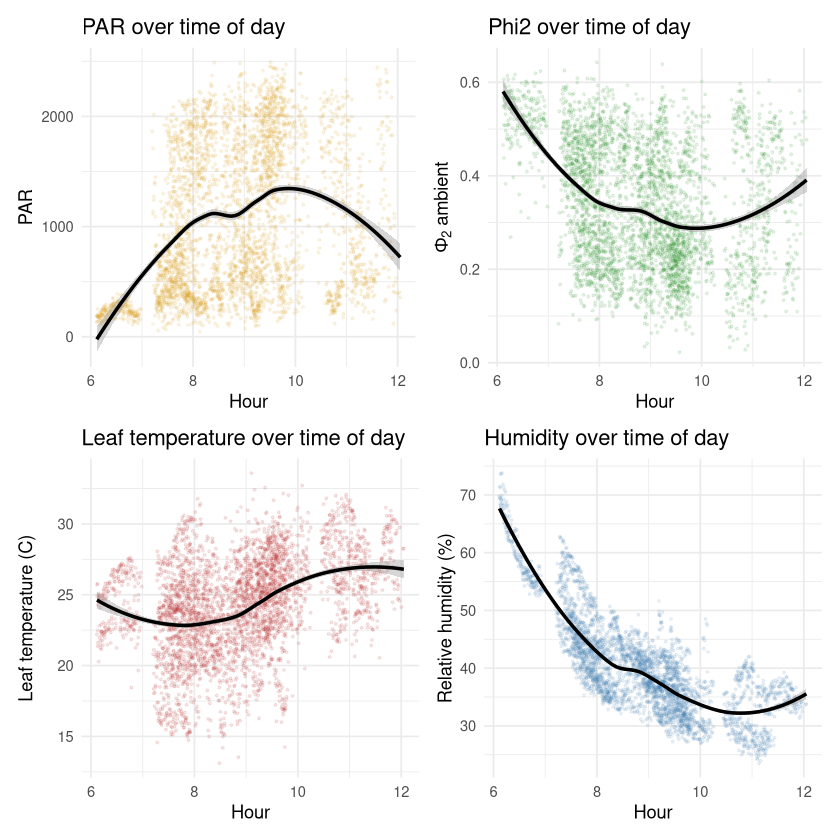

In [18]:
df$hour <- as.numeric(format(df$timestamp, "%H")) +
           as.numeric(format(df$timestamp, "%M")) / 60

p_t1 <- ggplot(df, aes(x = hour, y = PAR)) +
  geom_point(alpha = 0.1, size = 0.5, color = "goldenrod") +
  geom_smooth(method = "loess", color = "black") +
  labs(title = "PAR over time of day", x = "Hour", y = "PAR") +
  theme_minimal()

p_t2 <- ggplot(df, aes(x = hour, y = phi2_ambient)) +
  geom_point(alpha = 0.1, size = 0.5, color = "forestgreen") +
  geom_smooth(method = "loess", color = "black") +
  labs(title = "Phi2 over time of day", x = "Hour",
       y = expression(Phi[2] ~ ambient)) +
  theme_minimal()

p_t3 <- ggplot(df, aes(x = hour, y = leaf_temperature)) +
  geom_point(alpha = 0.1, size = 0.5, color = "firebrick") +
  geom_smooth(method = "loess", color = "black") +
  labs(title = "Leaf temperature over time of day", x = "Hour",
       y = "Leaf temperature (C)") +
  theme_minimal()

p_t4 <- ggplot(df, aes(x = hour, y = humidity)) +
  geom_point(alpha = 0.1, size = 0.5, color = "steelblue") +
  geom_smooth(method = "loess", color = "black") +
  labs(title = "Humidity over time of day", x = "Hour",
       y = "Relative humidity (%)") +
  theme_minimal()

(p_t1 + p_t2) / (p_t3 + p_t4)

## Spatial field layout

Visualise the field trial: each plot's position (Row x Column) coloured by
mean photosynthetic performance. Spatial patterns may indicate
soil gradients, shading, or edge effects.

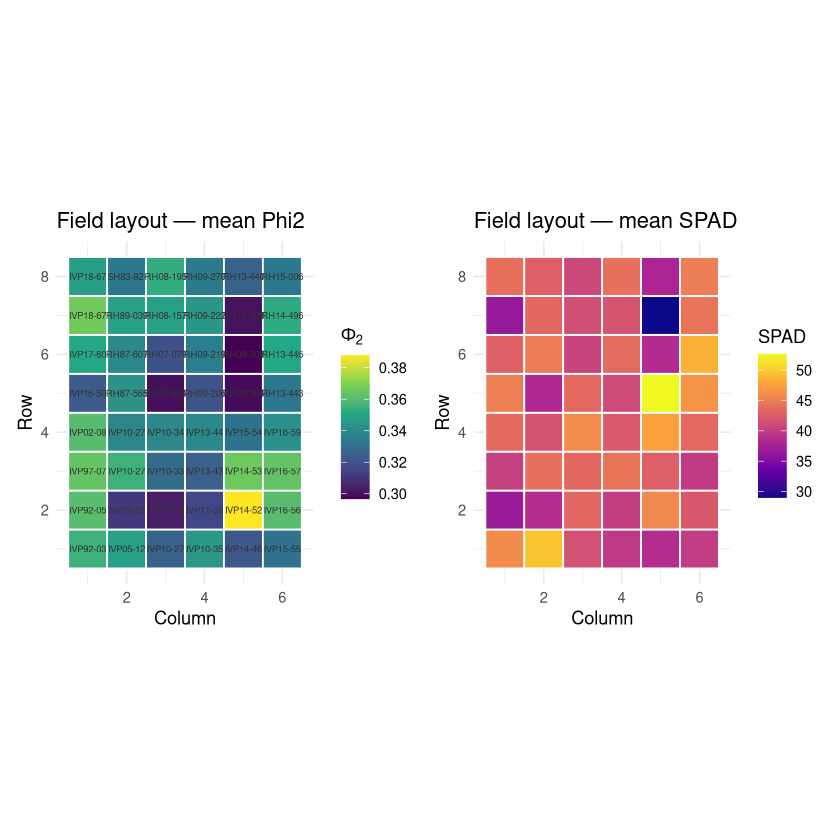

In [19]:
# Aggregate by field position
field_means <- df |>
  filter(!is.na(Row) & !is.na(Column)) |>
  group_by(Row, Column, Genotype) |>
  summarise(
    phi2     = mean(phi2_ambient, na.rm = TRUE),
    SPAD     = mean(SPAD, na.rm = TRUE),
    LEF      = mean(LEF_ambient, na.rm = TRUE),
    .groups  = "drop"
  )

p_s1 <- ggplot(field_means, aes(x = Column, y = Row, fill = phi2)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = substr(Genotype, 1, 8)), size = 2, color = "grey20") +
  scale_fill_viridis_c(option = "D") +
  labs(title = "Field layout — mean Phi2", fill = expression(Phi[2])) +
  coord_equal() +
  theme_minimal()

p_s2 <- ggplot(field_means, aes(x = Column, y = Row, fill = SPAD)) +
  geom_tile(color = "white", linewidth = 0.5) +
  scale_fill_viridis_c(option = "C") +
  labs(title = "Field layout — mean SPAD", fill = "SPAD") +
  coord_equal() +
  theme_minimal()

p_s1 + p_s2